 ## ***9. Which risk factors are more prevalent among patients who died?***

Reasoning: Compare proportions of anaemia, diabetes, smoking, and hypertension among deceased vs surviving patients. Useful visuals: Grouped bar charts.
Why it matters: Helps identify which comorbidities are more common in the high-risk group.




               risk_factor  died_count  survived_count
0                 diabetes          13             453
1                     copd           4             229
2           mod_severe_ckd          24             450
3  cerebrovascular_disease           6             144
4                 dementia           1             114


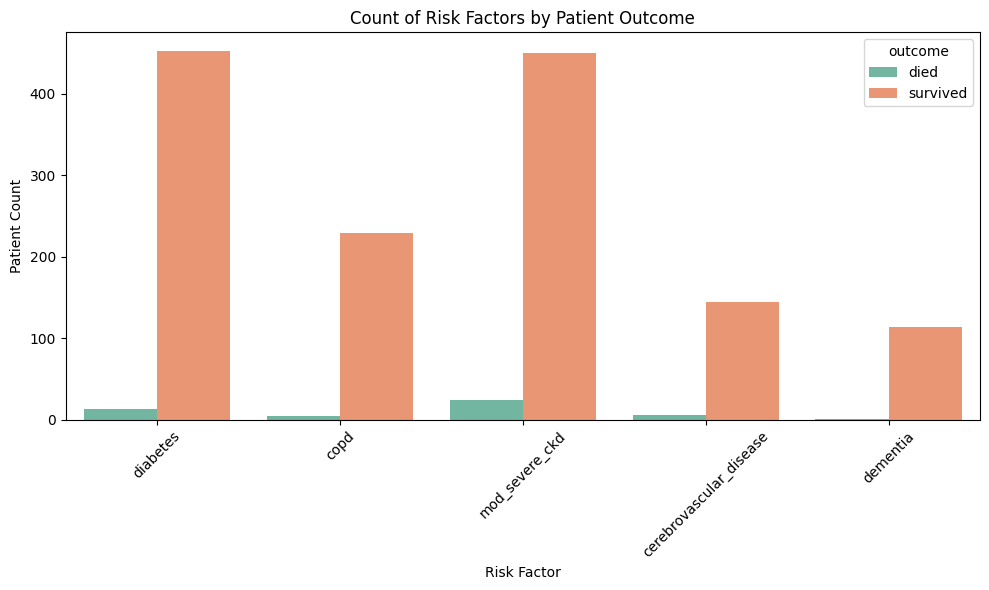

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Load datasets
hf_df = pd.read_csv("cleaned_files/heart_failure_merged.csv")

# 2) Merge on patient_id
df = hf_df.copy()

# 3) Define death outcome
df["died"] = (
    (df["in_hosp_outcome"].astype(str).str.lower() == "dead") |
    (df["mortality_28d"] == 1) |
    (df["death_3mo"] == 1) |
    (df["mortality_3mo"] == 1)
).astype(int)

# 4) Risk factors available in dataset
risk_factors = [
    "diabetes",
    "copd",
    "mod_severe_ckd",
    "cerebrovascular_disease",
    "dementia"
]

# Convert to binary counts: 0 = no, 1 = yes
for col in risk_factors:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
    df[col] = (df[col] > 0).astype(int)

# 5) Compare counts by outcome
comparison = []
for col in risk_factors:
    died_count = int(df.loc[df["died"] == 1, col].sum())
    survived_count = int(df.loc[df["died"] == 0, col].sum())

    comparison.append({
        "risk_factor": col,
        "died_count": died_count,
        "survived_count": survived_count
    })

comparison_df = pd.DataFrame(comparison)
print(comparison_df)

# 6) Prepare data for grouped bar chart
plot_df = comparison_df.melt(
    id_vars="risk_factor",
    value_vars=["died_count", "survived_count"],
    var_name="outcome",
    value_name="count"
)

plot_df["outcome"] = plot_df["outcome"].str.replace("_count", "", regex=False)

# 7) Plot grouped bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="risk_factor", y="count", hue="outcome", palette="Set2")
plt.title("Count of Risk Factors by Patient Outcome")
plt.ylabel("Patient Count")
plt.xlabel("Risk Factor")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()